<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/metropt2_lstm_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM Autoencoder — Détection d'anomalies sur MetroPT2
**Dataset** : MetroPT2 (Air Production Unit — Metro de Porto)  
**Méthode** : LSTM Autoencoder non-supervisé (reconstruction error)  
**Framework** : PyTorch

## Cellule 1 — Vérification GPU

In [2]:
# Cellule 1 : Vérification GPU
!nvidia-smi

Sat Apr 18 15:14:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cellule 2 — Installation des bibliothèques

In [3]:
# Cellule 2 : Installation (si nécessaire)
!pip install torch torchvision numpy pandas scikit-learn matplotlib seaborn --quiet

## Cellule 3 — Imports

In [4]:
# Cellule 3 : Imports
import torch
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

np.random.seed(42)
torch.manual_seed(42)

print('PyTorch version:', torch.__version__)
print('CUDA disponible :', torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA disponible : True


## Cellule 4 — Chargement de MetroPT2

In [5]:
# Cellule 4 : Chargement du dataset MetroPT2

# Option A : téléchargement direct depuis Zenodo
url = 'https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1'
df = pd.read_csv(url, parse_dates=['timestamp'])

# Option B : fichier local (décommenter si nécessaire)
# df = pd.read_csv('MetroPT2.csv', parse_dates=['timestamp'])

print('Shape :', df.shape)
print('Colonnes :', df.columns.tolist())
print('\nPremières lignes :')
df.head()

Shape : (7116940, 21)
Colonnes : ['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'gpsLat', 'gpsLong', 'gpsSpeed', 'gpsQuality']

Premières lignes :


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current,COMP,...,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,gpsLat,gpsLong,gpsSpeed,gpsQuality
0,2022-04-28 12:33:29.120,-0.014,8.060,1.136,-0.020,8.066,57.125,0.25,4.9100,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,41.140176,-8.609454,22.0,1.0
1,2022-04-28 12:33:30.111,0.156,8.058,-0.020,-0.018,8.066,57.200,0.25,4.7325,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,41.140229,-8.609471,22.0,1.0
2,2022-04-28 12:33:31.102,1.094,8.058,-0.026,-0.018,8.066,57.150,0.25,4.9100,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,41.140283,-8.609489,22.0,1.0
3,2022-04-28 12:33:32.093,2.482,8.058,-0.026,-0.018,8.064,57.125,0.25,4.8200,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,41.140338,-8.609505,22.0,1.0
4,2022-04-28 12:33:33.084,3.756,8.058,-0.024,-0.018,8.066,57.075,0.25,4.9100,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,41.140393,-8.609521,23.0,1.0


## Cellule 5 — Exploration des données

In [6]:
# Cellule 5 : Exploration — types, valeurs manquantes, statistiques
print('=== Types ===')
print(df.dtypes)

print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())

print('\n=== Statistiques descriptives ===')
df.describe()

=== Types ===
timestamp          datetime64[ns]
TP2                       float64
TP3                       float64
H1                        float64
DV_pressure               float64
Reservoirs                float64
Oil_temperature           float64
Flowmeter                 float64
Motor_current             float64
COMP                      float64
DV_eletric                float64
Towers                    float64
MPG                       float64
LPS                       float64
Pressure_switch           float64
Oil_level                 float64
Caudal_impulses           float64
gpsLat                    float64
gpsLong                   float64
gpsSpeed                  float64
gpsQuality                float64
dtype: object

=== Valeurs manquantes ===
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Flowmeter          0
Motor_current      0
COMP               0
DV_eletric         0

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current,COMP,...,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,gpsLat,gpsLong,gpsSpeed,gpsQuality
count,7116940,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,...,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06
mean,2022-06-12 19:18:42.335588352,6.395352e-01,8.963614e+00,8.290026e+00,-1.535030e-02,8.965358e+00,5.667782e+01,1.002711e+00,1.424005e+00,9.268929e-01,...,9.633536e-01,9.268918e-01,1.966295e-03,9.623148e-01,9.631000e-01,9.631346e-01,3.209552e+01,-6.732395e+00,8.151041e+00,7.791764e-01
min,2022-04-28 12:33:29.120000,-3.400000e-02,6.000000e-03,-3.400000e-02,-3.000000e-02,-3.861393e-03,3.177500e+01,2.500000e-01,-1.000000e-02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.694096e+00,0.000000e+00,0.000000e+00
25%,2022-05-20 17:56:31.419250176,-1.400000e-02,8.484000e+00,8.368000e+00,-2.200000e-02,8.486000e+00,5.397500e+01,2.500000e-01,3.750000e-02,1.000000e+00,...,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.112408e+01,-8.659117e+00,0.000000e+00,1.000000e+00
50%,2022-06-12 21:17:40.328499968,-1.200000e-02,8.944000e+00,8.842000e+00,-2.000000e-02,8.946000e+00,5.662500e+01,2.500000e-01,4.000000e-02,1.000000e+00,...,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.118319e+01,-8.646349e+00,0.000000e+00,1.000000e+00
75%,2022-07-05 06:37:28.497250048,-1.000000e-02,9.434000e+00,9.354000e+00,-1.800000e-02,9.436000e+00,5.910000e+01,2.500000e-01,3.750000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.121226e+01,-8.560203e+00,1.200000e+01,1.000000e+00
max,2022-07-28 12:24:34.839000,1.079400e+01,1.040800e+01,1.041400e+01,8.132000e+00,1.040010e+01,9.790000e+01,3.452287e+01,9.537500e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.124079e+01,0.000000e+00,2.690000e+02,1.000000e+00
std,NaN,2.373687e+00,6.116826e-01,2.389506e+00,1.100550e-01,6.112447e-01,4.834358e+00,3.915709e+00,2.052331e+00,2.603123e-01,...,1.878920e-01,2.603141e-01,4.429931e-02,1.904337e-01,1.885163e-01,1.884313e-01,1.708637e+01,3.584163e+00,1.528180e+01,4.148018e-01


## Cellule 6 — Visualisation des séries temporelles

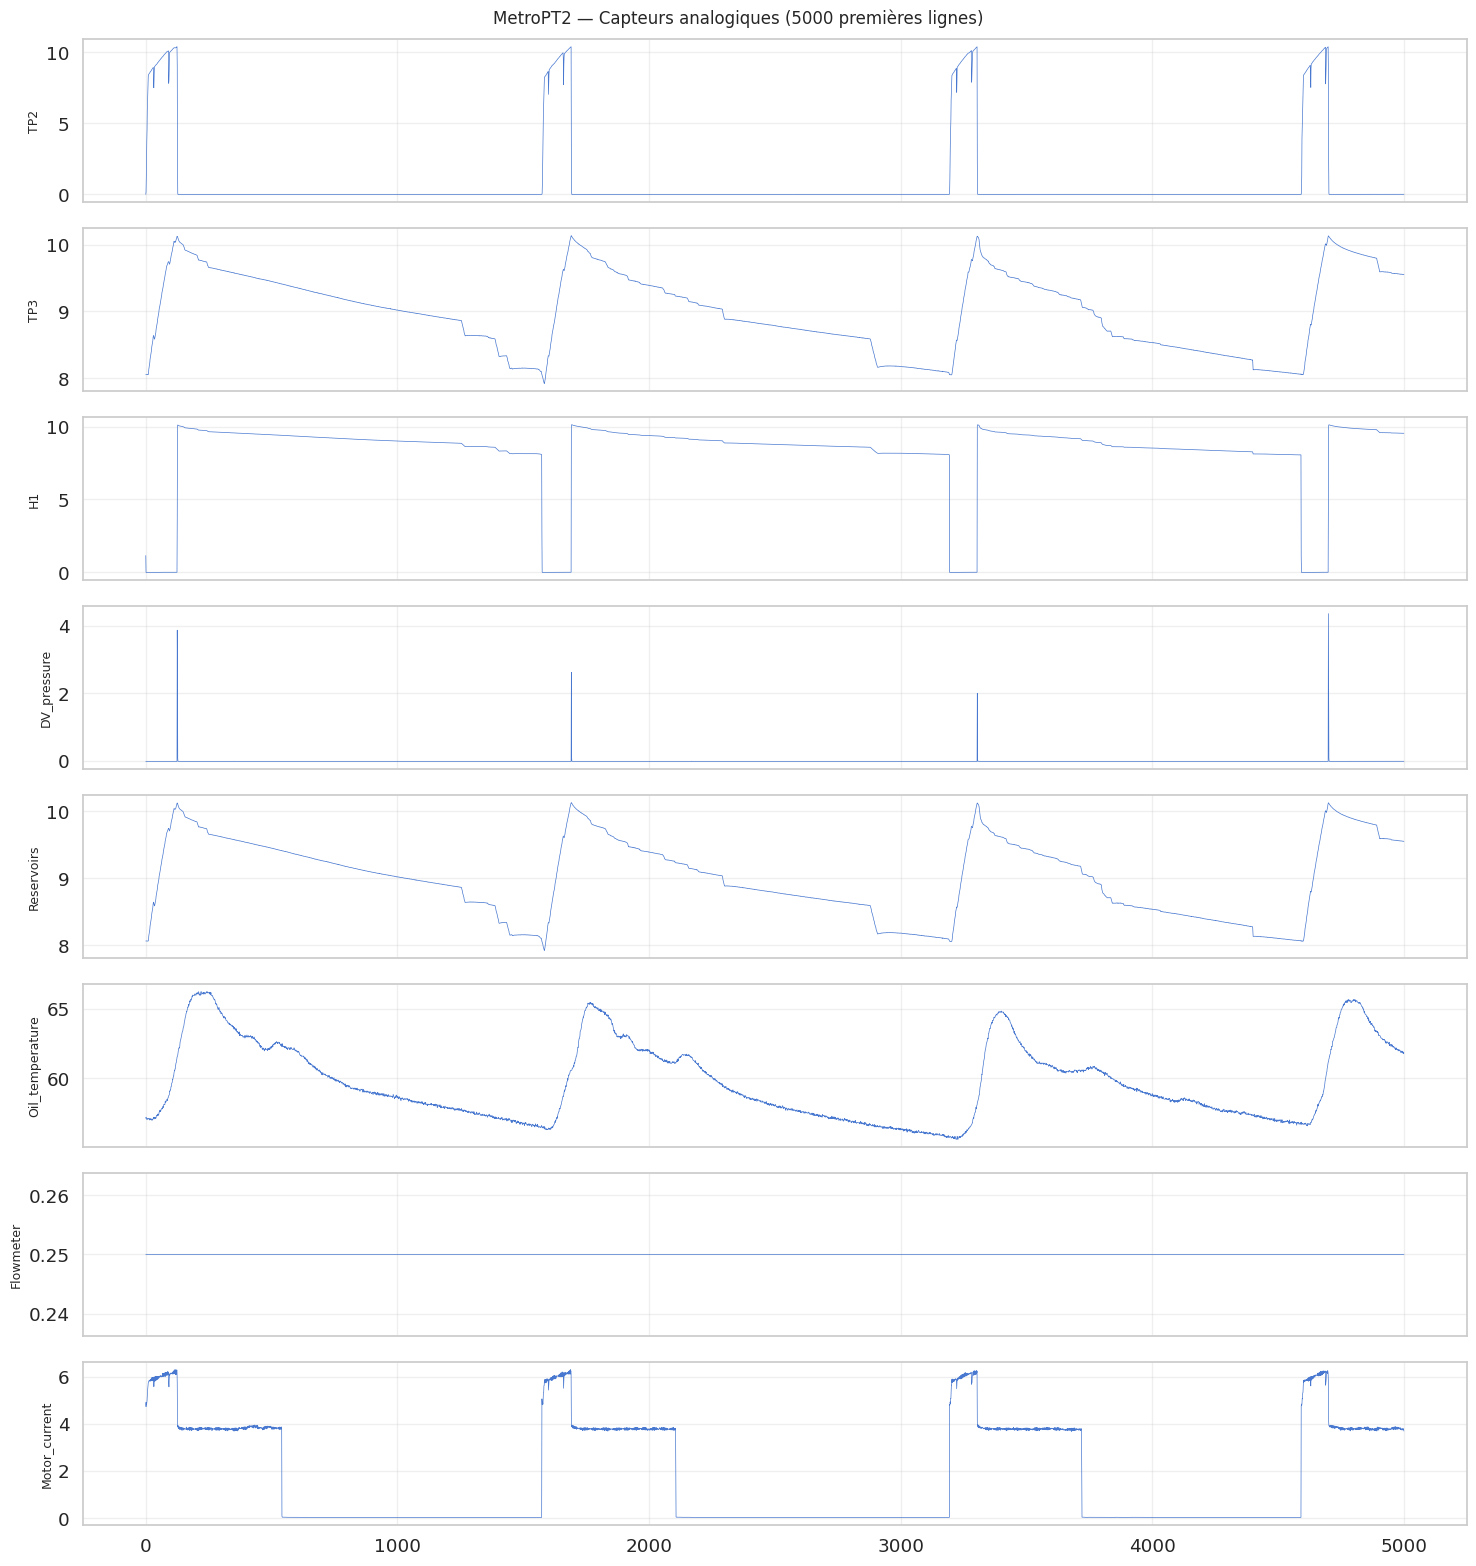

In [7]:
# Cellule 6 : Tracé des capteurs analogiques sur un échantillon
ANALOG_COLS = [
    'TP2', 'TP3', 'H1', 'DV_pressure',
    'Reservoirs', 'Oil_temperature',
    'Flowmeter', 'Motor_current'
]

# Affichage sur les 5000 premières lignes pour lisibilité
sample = df[ANALOG_COLS].iloc[:5000]

fig, axes = plt.subplots(len(ANALOG_COLS), 1, figsize=(15, 16), sharex=True)
for i, col in enumerate(ANALOG_COLS):
    axes[i].plot(sample[col].values, linewidth=0.5)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('MetroPT2 — Capteurs analogiques (5000 premières lignes)', fontsize=12)
plt.tight_layout()
plt.show()

## Cellule 7 — Prétraitement : nettoyage + normalisation

In [8]:
# Cellule 7 : Nettoyage et normalisation MinMax

# Supprimer les lignes avec valeurs manquantes sur les capteurs analogiques
df = df.dropna(subset=ANALOG_COLS).reset_index(drop=True)
print('Shape après nettoyage :', df.shape)

# Normalisation MinMax [0, 1]
scaler = MinMaxScaler()
df[ANALOG_COLS] = scaler.fit_transform(df[ANALOG_COLS])

print('Normalisation appliquée.')
df[ANALOG_COLS].describe()

Shape après nettoyage : (7116940, 21)
Normalisation appliquée.


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current
count,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06,7.116940e+06
mean,6.220311e-02,8.611435e-01,7.967100e-01,1.794867e-03,8.620964e-01,3.766022e-01,2.196230e-02,1.501969e-01
std,2.192175e-01,5.880433e-02,2.287046e-01,1.348383e-02,5.875113e-02,7.310939e-02,1.142510e-01,2.149601e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.847063e-03,8.150356e-01,8.041730e-01,9.801519e-04,8.160218e-01,3.357278e-01,0.000000e+00,4.975124e-03
50%,2.031769e-03,8.592578e-01,8.495406e-01,1.225190e-03,8.602357e-01,3.758034e-01,0.000000e+00,5.236973e-03
75%,2.216476e-03,9.063642e-01,8.985452e-01,1.470228e-03,9.073331e-01,4.132325e-01,0.000000e+00,3.938204e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [2]:
print(df.head())
print(df.shape)

NameError: name 'df' is not defined

## Cellule 8 — Construction des fenêtres temporelles (Sliding Windows)

In [1]:
# Cellule 8 : Fenêtres glissantes (sliding windows)
SEQ_LEN = 30  # 30 points = ~30 secondes (1 Hz)

def make_sequences(data, seq_len, cols):
    """
    Découpe un DataFrame en séquences de longueur seq_len.
    Retourne un array numpy de shape (N, seq_len, n_features).
    """
    arr = data[cols].values.astype(np.float32)
    sequences = []
    for i in range(len(arr) - seq_len):
        sequences.append(arr[i : i + seq_len])
    return np.array(sequences)

# Split temporel : 80% train, 20% test
split_idx = int(len(df) * 0.80)
train_raw = df.iloc[:split_idx]
test_raw  = df.iloc[split_idx:]

train_seqs = make_sequences(train_raw, SEQ_LEN, ANALOG_COLS)
test_seqs  = make_sequences(test_raw,  SEQ_LEN, ANALOG_COLS)

# Validation : 15% du train
train_seqs, val_seqs = train_test_split(
    train_seqs, test_size=0.15, random_state=42
)

n_features = len(ANALOG_COLS)  # 8
seq_len    = SEQ_LEN            # 30

print(f'Train  : {train_seqs.shape}')
print(f'Val    : {val_seqs.shape}')
print(f'Test   : {test_seqs.shape}')
print(f'n_features = {n_features}, seq_len = {seq_len}')

NameError: name 'df' is not defined

## Cellule 9 — Dataset PyTorch + DataLoaders

In [ ]:
# Cellule 9 : Dataset PyTorch et DataLoaders

class MetroPTDataset(Dataset):
    """Dataset PyTorch pour séquences MetroPT."""
    def __init__(self, sequences):
        # sequences : numpy array (N, seq_len, n_features)
        self.sequences = torch.tensor(sequences, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]  # shape : (seq_len, n_features)


BATCH_SIZE = 64

train_loader = DataLoader(
    MetroPTDataset(train_seqs),
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    MetroPTDataset(val_seqs),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    MetroPTDataset(test_seqs),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Batches train : {len(train_loader)}')
print(f'Batches val   : {len(val_loader)}')
print(f'Batches test  : {len(test_loader)}')

## Cellule 10 — Architecture : Encoder

In [ ]:
# Cellule 10 : Encoder LSTM
class Encoder(nn.Module):
    """
    Compresse une séquence (seq_len, n_features)
    en un vecteur latent (embedding_dim,).
    """
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(Encoder, self).__init__()
        self.seq_len       = seq_len
        self.n_features    = n_features
        self.embedding_dim = embedding_dim
        self.hidden_dim    = 2 * embedding_dim  # 128

        # Première couche LSTM : n_features -> hidden_dim
        self.rnn1 = nn.LSTM(
            input_size=n_features,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )
        # Deuxième couche LSTM : hidden_dim -> embedding_dim
        self.rnn2 = nn.LSTM(
            input_size=self.hidden_dim,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )

    def forward(self, x):
        # x : (batch, seq_len, n_features)
        x, _       = self.rnn1(x)
        _, (h_n, _) = self.rnn2(x)
        # h_n : (1, batch, embedding_dim) -> (batch, embedding_dim)
        return h_n.squeeze(0)

## Cellule 11 — Architecture : Decoder

In [ ]:
# Cellule 11 : Decoder LSTM
class Decoder(nn.Module):
    """
    Reconstruit une séquence (seq_len, n_features)
    à partir du vecteur latent (embedding_dim,).
    """
    def __init__(self, seq_len, embedding_dim=64, n_features=8):
        super(Decoder, self).__init__()
        self.seq_len    = seq_len
        self.hidden_dim = 2 * embedding_dim  # 128

        # Première couche LSTM : embedding_dim -> embedding_dim
        self.rnn1 = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )
        # Deuxième couche LSTM : embedding_dim -> hidden_dim
        self.rnn2 = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )
        # Couche linéaire finale : hidden_dim -> n_features
        self.output_layer = nn.Linear(self.hidden_dim, n_features)

    def forward(self, z):
        # z : (batch, embedding_dim)
        # Répéter le vecteur latent sur seq_len pas de temps
        z = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        # z : (batch, seq_len, embedding_dim)
        x, _ = self.rnn1(z)
        x, _ = self.rnn2(x)
        # x : (batch, seq_len, hidden_dim)
        return self.output_layer(x)
        # output : (batch, seq_len, n_features)

## Cellule 12 — Architecture : LSTMAutoencoder complet

In [ ]:
# Cellule 12 : Modèle complet LSTMAutoencoder
class LSTMAutoencoder(nn.Module):
    """Autoencoder LSTM pour détection d'anomalies."""
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = Encoder(seq_len, n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        z = self.encoder(x)  # compression
        return self.decoder(z)  # reconstruction


# Instanciation et envoi sur GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

EMBEDDING_DIM = 64
model = LSTMAutoencoder(seq_len, n_features, embedding_dim=EMBEDDING_DIM).to(device)
print(model)

# Nombre de paramètres
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')

## Cellule 13 — Fonction de perte + Optimiseur

In [ ]:
# Cellule 13 : Loss function et optimiseur

# MSE : mesure l'écart entre séquence originale et reconstruite
loss_fn = nn.MSELoss(reduction='mean')

# Adam avec learning rate 1e-3
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Scheduler : réduit le LR si la val loss ne s'améliore pas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print('Loss     : MSELoss')
print('Optimiseur : Adam (lr=1e-3)')
print('Scheduler  : ReduceLROnPlateau (patience=5)')

## Cellule 14 — Boucle d'entraînement

In [ ]:
# Cellule 14 : Boucle d'entraînement complète
N_EPOCHS    = 50
best_val    = float('inf')
best_state  = None
train_losses = []
val_losses   = []

for epoch in range(1, N_EPOCHS + 1):

    # ── Entraînement ──────────────────────────────────
    model.train()
    t_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)          # (B, seq_len, n_features)
        optimizer.zero_grad()
        output = model(batch)             # reconstruction
        loss   = loss_fn(output, batch)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(batch)
    t_loss /= len(train_seqs)

    # ── Validation ────────────────────────────────────
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch  = batch.to(device)
            output = model(batch)
            v_loss += loss_fn(output, batch).item() * len(batch)
    v_loss /= len(val_seqs)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    # Scheduler step
    scheduler.step(v_loss)

    # Sauvegarde du meilleur modèle
    if v_loss < best_val:
        best_val   = v_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f'[{epoch:3d}/{N_EPOCHS}]  Train Loss: {t_loss:.6f}  |  Val Loss: {v_loss:.6f}')

# Recharger le meilleur modèle
model.load_state_dict(best_state)
torch.save(best_state, 'metropt2_lstm_ae_best.pt')
print(f'\nMeilleure Val Loss : {best_val:.6f}')
print('Modèle sauvegardé -> metropt2_lstm_ae_best.pt')

## Cellule 15 — Courbe Loss Train / Validation

In [ ]:
# Cellule 15 : Courbe d'apprentissage
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=1.5)
plt.plot(val_losses,   label='Val Loss',   linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MetroPT2 — Courbe d\'apprentissage LSTM Autoencoder')
plt.legend()
plt.tight_layout()
plt.show()

## Cellule 16 — Calcul des reconstruction errors

In [ ]:
# Cellule 16 : Calcul des erreurs de reconstruction

def get_reconstruction_errors(loader, model, device):
    """
    Retourne une liste d'erreurs MSE par séquence.
    """
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)         # (B, seq_len, n_features)
            output = model(batch)             # (B, seq_len, n_features)
            # MSE par séquence : moyenne sur seq_len et n_features
            mse = ((output - batch) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy().tolist())
    return np.array(errors)


train_errors = get_reconstruction_errors(train_loader, model, device)
val_errors   = get_reconstruction_errors(val_loader,   model, device)
test_errors  = get_reconstruction_errors(test_loader,  model, device)

print(f'Train errors — mean: {train_errors.mean():.5f}  std: {train_errors.std():.5f}')
print(f'Val   errors — mean: {val_errors.mean():.5f}  std: {val_errors.std():.5f}')
print(f'Test  errors — mean: {test_errors.mean():.5f}  std: {test_errors.std():.5f}')

## Cellule 17 — Calcul du seuil (Threshold)

In [ ]:
# Cellule 17 : Définition du seuil d'anomalie

# Méthode 1 : percentile 95 des erreurs d'entraînement
THRESHOLD_P95 = np.percentile(train_errors, 95)

# Méthode 2 : mean + 3*std (règle statistique)
THRESHOLD_STD = train_errors.mean() + 3 * train_errors.std()

# Choix du seuil (utiliser l'un ou l'autre)
THRESHOLD = THRESHOLD_P95

print(f'Seuil P95  : {THRESHOLD_P95:.6f}')
print(f'Seuil Mean+3STD : {THRESHOLD_STD:.6f}')
print(f'Seuil retenu : {THRESHOLD:.6f}')

## Cellule 18 — Distribution des erreurs de reconstruction

In [ ]:
# Cellule 18 : Distribution des erreurs — Train vs Test
plt.figure(figsize=(12, 5))

plt.hist(train_errors, bins=100, alpha=0.6, color='steelblue',
         label=f'Train (n={len(train_errors):,})')
plt.hist(test_errors,  bins=100, alpha=0.6, color='darkorange',
         label=f'Test (n={len(test_errors):,})')
plt.axvline(THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {THRESHOLD:.5f}')

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Nombre de séquences')
plt.title('MetroPT2 — Distribution des erreurs de reconstruction')
plt.legend()
plt.tight_layout()
plt.show()

## Cellule 19 — Timeline des anomalies détectées

In [ ]:
# Cellule 19 : Visualisation temporelle des anomalies

# Prédictions : 1 = anomalie, 0 = normal
test_preds = (test_errors > THRESHOLD).astype(int)

# Index temporels correspondants dans test_raw
test_timestamps = test_raw['timestamp'].values[SEQ_LEN:]

plt.figure(figsize=(16, 4))
plt.plot(test_errors, linewidth=0.6, color='steelblue',
         label='Reconstruction error')
plt.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold = {THRESHOLD:.5f}')

anomaly_idx = np.where(test_preds == 1)[0]
plt.scatter(anomaly_idx, test_errors[anomaly_idx],
            color='red', s=6, zorder=5, label='Anomalie détectée')

plt.xlabel('Index séquence (test set)')
plt.ylabel('MSE')
plt.title('MetroPT2 — Détection d\'anomalies (timeline)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Anomalies détectées : {test_preds.sum():,} / {len(test_preds):,}')
print(f'Taux d\'anomalie   : {test_preds.mean() * 100:.2f}%')

## Cellule 20 — Reconstruction d'une séquence normale vs anomale

In [ ]:
# Cellule 20 : Comparaison reconstruction — normal vs anomalie

def plot_reconstruction(seq_idx, loader_seqs, title):
    """
    Affiche la séquence originale vs reconstruite pour un capteur.
    seq_idx : index dans le dataset
    """
    seq = torch.tensor(loader_seqs[seq_idx]).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        recon = model(seq).cpu().numpy()[0]  # (seq_len, n_features)
    original = loader_seqs[seq_idx]           # (seq_len, n_features)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i, col in enumerate(ANALOG_COLS):
        axes[i].plot(original[:, i], label='Original', linewidth=1.5)
        axes[i].plot(recon[:, i],    label='Reconstruit', linewidth=1.5,
                     linestyle='--')
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
        axes[i].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Trouver un exemple normal (faible erreur)
normal_idx  = np.argmin(test_errors)
# Trouver un exemple anomalie (forte erreur)
anomaly_idx_ex = np.argmax(test_errors)

plot_reconstruction(
    normal_idx, test_seqs,
    f'Séquence NORMALE — idx={normal_idx} | MSE={test_errors[normal_idx]:.5f}'
)
plot_reconstruction(
    anomaly_idx_ex, test_seqs,
    f'Séquence ANOMALIE — idx={anomaly_idx_ex} | MSE={test_errors[anomaly_idx_ex]:.5f}'
)

## Cellule 21 — Matrice de confusion (si labels disponibles)

In [ ]:
# Cellule 21 : Évaluation avec labels (si disponibles)
# MetroPT2 n'a pas de labels officiels par séquence.
# On peut construire des pseudo-labels si on a les timestamps de pannes.

# ── Exemple avec pseudo-labels (adapter selon rapport de maintenance) ──
# Supposons que les anomalies sont dans la dernière semaine du dataset
# (à remplacer par les vraies dates de pannes si connues)

# Création d'un DataFrame résultat
results_df = pd.DataFrame({
    'reconstruction_error': test_errors,
    'predicted_anomaly': test_preds
})

print('=== Résultats de détection ===')
print(results_df['predicted_anomaly'].value_counts())
print(f'\nNormales  : {(test_preds == 0).sum():,}')
print(f'Anomalies : {(test_preds == 1).sum():,}')
print(f'\nSeuil utilisé : {THRESHOLD:.6f}')
results_df.head(10)

## Cellule 22 — Heatmap des erreurs par capteur

In [ ]:
# Cellule 22 : Contribution de chaque capteur à l'erreur de reconstruction

def get_per_feature_errors(loader, model, device):
    """
    Retourne l'erreur MSE par capteur (feature).
    Output shape : (N, n_features)
    """
    model.eval()
    all_errors = []
    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)
            output = model(batch)
            # MSE par séquence et par capteur : mean sur seq_len seulement
            mse = ((output - batch) ** 2).mean(dim=1)  # (B, n_features)
            all_errors.append(mse.cpu().numpy())
    return np.concatenate(all_errors, axis=0)  # (N, n_features)


test_feature_errors = get_per_feature_errors(test_loader, model, device)

# Moyenne des erreurs par capteur
mean_errors_per_feature = test_feature_errors.mean(axis=0)

plt.figure(figsize=(10, 4))
bars = plt.bar(ANALOG_COLS, mean_errors_per_feature, color='steelblue', edgecolor='white')
plt.xlabel('Capteur')
plt.ylabel('MSE moyen')
plt.title('MetroPT2 — Erreur de reconstruction moyenne par capteur')
plt.xticks(rotation=15)
for bar, val in zip(bars, mean_errors_per_feature):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Cellule 23 — Extension MetroPT1 / MetroPT3 (même pipeline)

In [ ]:
# Cellule 23 : Charger et combiner MetroPT1 + MetroPT2 + MetroPT3
# (décommenter selon le dataset voulu)

URLS = {
    'MetroPT1': 'https://zenodo.org/records/7766691/files/MetroPT.csv?download=1',
    'MetroPT2': 'https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1',
    'MetroPT3': 'https://archive.ics.uci.edu/ml/machine-learning-databases/00791/MetroPT3(2).csv'
}

# Exemple : charger les 3 et les concaténer
# dfs = []
# for name, url in URLS.items():
#     print(f'Chargement {name}...')
#     tmp = pd.read_csv(url, parse_dates=['timestamp'])
#     tmp['source'] = name
#     dfs.append(tmp)
# df_all = pd.concat(dfs, ignore_index=True)
# print('Dataset combiné :', df_all.shape)

# Le pipeline de preprocessing reste identique :
# df_all = df_all.dropna(subset=ANALOG_COLS)
# df_all[ANALOG_COLS] = scaler.fit_transform(df_all[ANALOG_COLS])
# ... (même que cellules 7 à 14)

print('URLs disponibles :')
for k, v in URLS.items():
    print(f'  {k} -> {v}')

## Cellule 24 — Sauvegarde des résultats

In [ ]:
# Cellule 24 : Export des résultats et du scaler
import pickle

# Sauvegarder le scaler (pour inférence future)
with open('metropt2_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Sauvegarder les erreurs
results_df.to_csv('metropt2_anomaly_results.csv', index=False)

print('Fichiers sauvegardés :')
print('  metropt2_lstm_ae_best.pt         — poids du modèle')
print('  metropt2_scaler.pkl              — scaler MinMax')
print('  metropt2_anomaly_results.csv     — résultats de détection')
print(f'\nSeuil retenu : {THRESHOLD:.6f}')
print(f'Anomalies détectées dans le test set : {test_preds.sum():,} ({test_preds.mean()*100:.1f}%)')